<a href="https://colab.research.google.com/github/venky1602/Trip-fare-project/blob/main/p3_TripFare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/taxi_fare.csv')
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,-73.976746,40.765152,1.0,N,-74.004265,40.746128,1.0,9.0,0.5,0.5,2.05,0.00,0.3,12.35
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,-73.983482,40.767925,1.0,N,-74.005943,40.733166,1.0,11.0,0.5,0.5,3.05,0.00,0.3,15.35
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,-73.782021,40.644810,1.0,N,-73.974541,40.675770,1.0,54.5,0.5,0.5,8.00,0.00,0.3,63.80
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,-73.863419,40.769814,1.0,N,-73.969650,40.757767,1.0,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,-73.971741,40.792183,3.0,N,-74.177170,40.695053,1.0,98.0,0.0,0.0,0.00,15.50,0.3,113.80


In [ ]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [ ]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Earth radius in kilometers
    return c * r

df['trip_distance'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                                df['dropoff_latitude'], df['dropoff_longitude'])


In [ ]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek
df['is_weekend'] = df['pickup_day'].apply(lambda x: 1 if x >= 5 else 0)
df['am_pm'] = df['pickup_hour'].apply(lambda x: 'AM' if x < 12 else 'PM')
df['is_night'] = df['pickup_hour'].apply(lambda x: 1 if (x < 6 or x > 22) else 0)


In [ ]:
df[['trip_distance', 'pickup_hour', 'pickup_day', 'is_weekend', 'am_pm', 'is_night']].head()


,trip_distance,pickup_hour,pickup_day,is_weekend,am_pm,is_night
0,3.138096,0,1,0,AM,1
1,4.303331,0,1,0,AM,1
2,16.600142,0,1,0,AM,1
3,9.046547,0,1,0,AM,1
4,20.400022,0,1,0,AM,1


In [ ]:
# Remove zero or negative fares
df = df[df['fare_amount'] > 0]

# Remove extreme total_amount (fare above $300 usually unrealistic)
df = df[df['total_amount'] < 300]

# Remove trips with zero or negative trip distance
df = df[df['trip_distance'] > 0]

# Remove passengers_count outliers (usually 1–6 is valid)
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]

# Remove trips with 0 duration (pickup and dropoff at same second)
df = df[df['tpep_pickup_datetime'] != df['tpep_dropoff_datetime']]

# Reset index after filtering
df.reset_index(drop=True, inplace=True)


In [ ]:
# Step A: Basic Shape and Preview
print("Shape of dataset:", df.shape)
display(df.head())

Shape of dataset: (47220, 24)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_distance,pickup_hour,pickup_day,is_weekend,am_pm,is_night
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,-73.976746,40.765152,1.0,N,-74.004265,40.746128,...,2.05,0.0,0.3,12.35,3.138096,0,1,0,AM,1
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,-73.983482,40.767925,1.0,N,-74.005943,40.733166,...,3.05,0.0,0.3,15.35,4.303331,0,1,0,AM,1
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,-73.782021,40.644810,1.0,N,-73.974541,40.675770,...,8.00,0.0,0.3,63.80,16.600142,0,1,0,AM,1
3,1,2016-03-01 00:00:01,2016-03-01 00:16:04,1,-73.788773,40.647758,1.0,N,-73.829208,40.712345,...,0.00,0.0,0.3,21.80,7.950066,0,1,0,AM,1
4,1,2016-03-01 00:00:01,2016-03-01 00:05:00,1,-73.958221,40.764641,1.0,N,-73.967896,40.762901,...,2.00,0.0,0.3,8.80,0.837395,0,1,0,AM,1


In [ ]:
# Step B: Datatypes and Non-Null Counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47220 entries, 0 to 47219
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               47220 non-null  int64         
 1   tpep_pickup_datetime   47220 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  47220 non-null  datetime64[ns]
 3   passenger_count        47220 non-null  int64         
 4   pickup_longitude       47220 non-null  float64       
 5   pickup_latitude        47220 non-null  float64       
 6   RatecodeID             47220 non-null  float64       
 7   store_and_fwd_flag     47220 non-null  object        
 8   dropoff_longitude      47220 non-null  float64       
 9   dropoff_latitude       47220 non-null  float64       
 10  payment_type           47220 non-null  float64       
 11  fare_amount            47220 non-null  float64       
 12  extra                  47220 non-null  float64       
 13  m

In [ ]:
# Step C: Missing Values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
trip_distance            0
pickup_hour              0
pickup_day               0
is_weekend               0
am_pm                    0
is_night                 0
dtype: int64


In [ ]:
# Step D: Duplicate Rows
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [ ]:
# Step E: Descriptive Statistics
print("\nDescriptive Statistics:\n", df.describe())


Descriptive Statistics:
            VendorID           tpep_pickup_datetime  \
count  47220.000000                          47220   
mean       1.998560  2016-03-10 08:30:33.797035264   
min        1.000000            2016-03-01 00:00:00   
25%        2.000000            2016-03-10 08:11:17   
50%        2.000000            2016-03-10 09:12:48   
75%        2.000000  2016-03-10 10:22:50.249999872   
max        2.000000            2016-03-10 11:38:48   
std        0.037921                            NaN   

               tpep_dropoff_datetime  passenger_count  pickup_longitude  \
count                          47220     47220.000000      47220.000000   
mean   2016-03-10 08:48:13.033396736         2.027552        -73.937009   
min              2016-03-01 00:01:40         1.000000       -121.933250   
25%              2016-03-10 08:25:40         1.000000        -73.990982   
50%       2016-03-10 09:28:18.500000         1.000000        -73.979393   
75%    2016-03-10 10:38:14.249999872 

In [ ]:
# Step F: Unique values in categorical columns
print("\nUnique store_and_fwd_flag:", df['store_and_fwd_flag'].unique())
print("Unique payment_type:", df['payment_type'].unique())
print("Unique RatecodeID:", df['RatecodeID'].unique())


Unique store_and_fwd_flag: ['N' 'Y']
Unique payment_type: [1. 3. 2.]
Unique RatecodeID: [1. 2. 5. 3. 4.]


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')


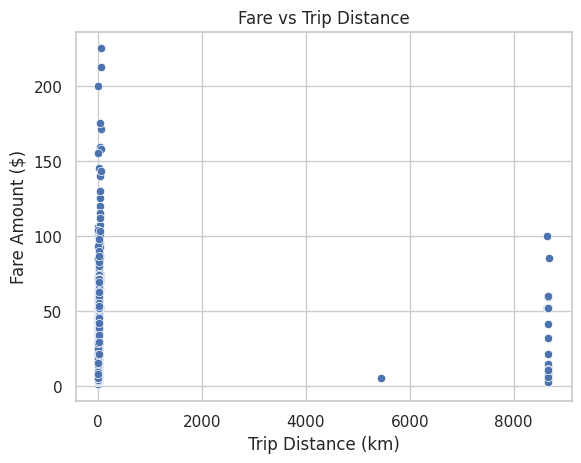

In [ ]:
sns.scatterplot(x='trip_distance', y='fare_amount', data=df)
plt.title('Fare vs Trip Distance')
plt.xlabel('Trip Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.show()


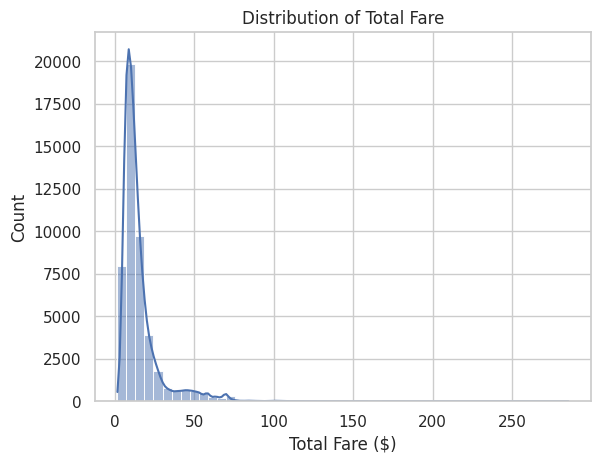

In [ ]:
sns.histplot(df['total_amount'], bins=50, kde=True)
plt.title('Distribution of Total Fare')
plt.xlabel('Total Fare ($)')
plt.show()


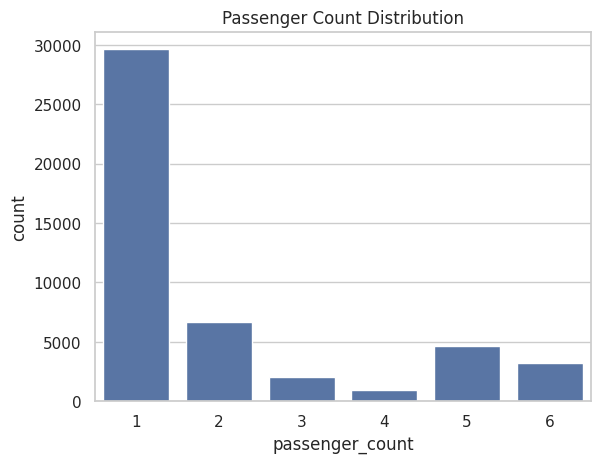

In [ ]:
sns.countplot(x='passenger_count', data=df)
plt.title('Passenger Count Distribution')
plt.show()


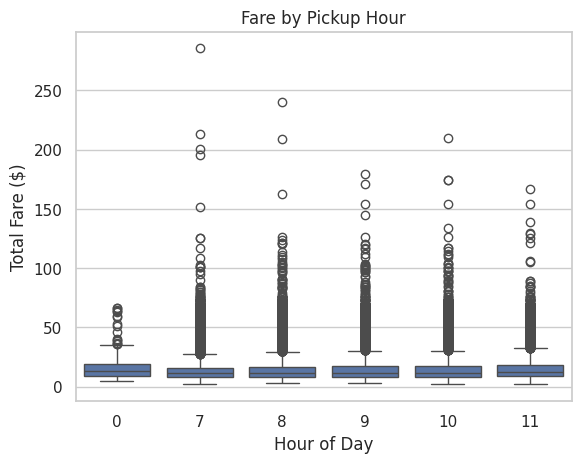

In [ ]:
sns.boxplot(x='pickup_hour', y='total_amount', data=df)
plt.title('Fare by Pickup Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Fare ($)')
plt.show()


In [ ]:
# Check skewness
df[['trip_distance', 'fare_amount', 'total_amount']].skew()


,0
trip_distance,31.412107
fare_amount,3.539863
total_amount,3.604192


In [ ]:
df['log_trip_distance'] = np.log1p(df['trip_distance'])
df['log_fare_amount'] = np.log1p(df['fare_amount'])
df['log_total_amount'] = np.log1p(df['total_amount'])  # Optional


In [ ]:
# IQR outlier removal function
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Apply to key columns
df = remove_outliers_iqr(df, 'fare_amount')
df = remove_outliers_iqr(df, 'trip_distance')
df = remove_outliers_iqr(df, 'total_amount')

# Reset index
df.reset_index(drop=True, inplace=True)


In [ ]:
# Encode store_and_fwd_flag
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

# Encode am_pm
df['am_pm'] = df['am_pm'].map({'AM': 0, 'PM': 1})

# No change for RatecodeID or payment_type (already numeric)


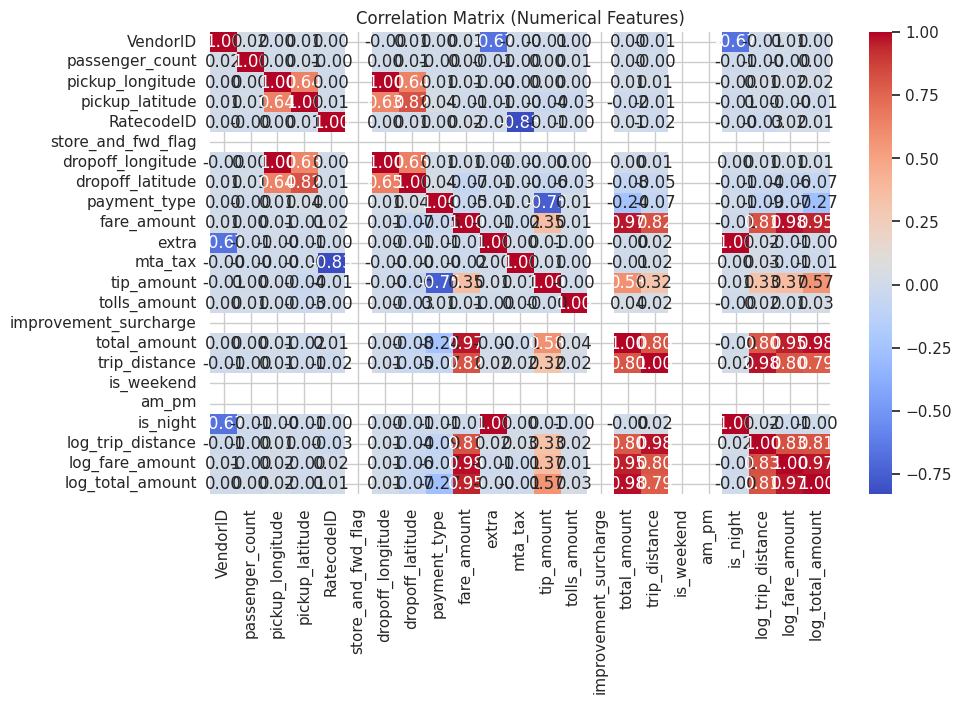

Correlation with log_fare_amount:
 log_fare_amount          1.000000
fare_amount              0.978687
log_total_amount         0.969720
total_amount             0.952236
log_trip_distance        0.826981
trip_distance            0.804639
tip_amount               0.367625
pickup_longitude         0.017850
RatecodeID               0.016181
dropoff_longitude        0.013827
tolls_amount             0.012904
VendorID                 0.009514
passenger_count         -0.000502
pickup_latitude         -0.002454
extra                   -0.012886
is_night                -0.012886
mta_tax                 -0.014725
dropoff_latitude        -0.060627
payment_type            -0.067719
store_and_fwd_flag            NaN
improvement_surcharge         NaN
is_weekend                    NaN
am_pm                         NaN
Name: log_fare_amount, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).copy()

# Compute correlation with target
correlation = numerical_cols.corr()['log_fare_amount'].sort_values(ascending=False)

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Numerical Features)')
plt.show()

# Display correlation with target
print("Correlation with log_fare_amount:\n", correlation)


In [ ]:
from sklearn.model_selection import train_test_split

# Feature columns
feature_cols = [
    'VendorID', 'passenger_count', 'store_and_fwd_flag',
    'RatecodeID', 'payment_type',
    'log_trip_distance', 'pickup_hour', 'pickup_day',
    'is_weekend', 'am_pm', 'is_night'
]

# Target
target = 'log_fare_amount'

# Prepare X and y
X = df[feature_cols]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {"R2": r2, "RMSE": rmse, "MAE": mae}

# Convert to DataFrame for display
pd.DataFrame(results).T.sort_values("R2", ascending=False)


,R2,RMSE,MAE
GradientBoosting,0.699790,0.197497,0.152310
Ridge,0.690488,0.200533,0.154254
LinearRegression,0.690410,0.200558,0.154261
RandomForest,0.629944,0.219271,0.169826
Lasso,-0.000002,0.360452,0.298059


In [ ]:
import pytz

# Define timezone objects
utc = pytz.timezone('UTC')
eastern = pytz.timezone('US/Eastern')

# Convert pickup_datetime from UTC to EDT
df['pickup_datetime_local'] = df['tpep_pickup_datetime'].dt.tz_localize(utc).dt.tz_convert(eastern)

# Now extract features again from local time
df['pickup_hour'] = df['pickup_datetime_local'].dt.hour
df['pickup_day'] = df['pickup_datetime_local'].dt.dayofweek
df['is_weekend'] = df['pickup_day'].apply(lambda x: 1 if x >= 5 else 0)
df['am_pm'] = df['pickup_hour'].apply(lambda x: 'AM' if x < 12 else 'PM')
df['is_night'] = df['pickup_hour'].apply(lambda x: 1 if (x < 6 or x > 22) else 0)


In [ ]:
# Convert 'AM'/'PM' to 0/1 if not already done
df['am_pm'] = df['am_pm'].map({'AM': 0, 'PM': 1})


In [ ]:
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})


In [ ]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values:\n", missing[missing > 0])


Missing values:
 store_and_fwd_flag    39921
dtype: int64


In [ ]:
df.drop(columns=['store_and_fwd_flag'], inplace=True)


In [ ]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Step 1: Select categorical features
cat_features = ['VendorID', 'passenger_count', 'RatecodeID',
                'payment_type', 'is_weekend', 'am_pm', 'is_night', 'pickup_day']
X_cat = df[cat_features]

# Step 2: Discretize the continuous target into quantile bins
# e.g., 4 quartile bins
df['fare_bin'] = pd.qcut(df['log_fare_amount'], q=4, labels=False)

# Step 3: Run chi-square test
chi_scores, _ = chi2(X_cat, df['fare_bin'])

# Step 4: Show results
chi_df = pd.DataFrame({
    'Feature': cat_features,
    'Chi2 Score': chi_scores.flatten()
}).sort_values(by='Chi2 Score', ascending=False)

print("✅ Chi-Square Scores (Target Binned into Quartiles):")
print(chi_df)


✅ Chi-Square Scores (Target Binned into Quartiles):
           Feature  Chi2 Score
3     payment_type   37.443897
6         is_night    3.979022
5            am_pm    3.777488
1  passenger_count    0.937084
7       pickup_day    0.033882
2       RatecodeID    0.020186
0         VendorID    0.002095
4       is_weekend         NaN


In [ ]:
y_cat = MinMaxScaler().fit_transform(df[['log_fare_amount']])


In [ ]:
# ✅ Fix the shape of y_cat to 1D
y_cat = MinMaxScaler().fit_transform(df[['log_fare_amount']]).ravel()

In [ ]:
print(df['is_weekend'].value_counts())


is_weekend
0    39921
Name: count, dtype: int64


In [ ]:
final_features = [
    'VendorID',               # categorical (encoded)
    'passenger_count',        # categorical (encoded)
    'RatecodeID',             # categorical (encoded)
    'payment_type',           # categorical (encoded)
    'log_trip_distance',      # numerical (important)
    'pickup_hour',            # time feature
    'pickup_day',             # day of week
    'am_pm',                  # 0 = AM, 1 = PM
    'is_night'                # 1 = late-night/early-morning
]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define X and y
X = df[final_features]
y = df['log_fare_amount']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest (can be replaced with best model)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"✅ Model Evaluation:\nR²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")


✅ Model Evaluation:
R²: 0.6297 | RMSE: 0.2193 | MAE: 0.1700


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# Use your finalized feature list
final_features = [
    'VendorID', 'passenger_count', 'RatecodeID', 'payment_type',
    'log_trip_distance', 'pickup_hour', 'pickup_day', 'am_pm', 'is_night'
]

# Sample data for faster training
df_sampled = df.sample(n=25000, random_state=42)

X = df_sampled[final_features]
y = df_sampled['log_fare_amount']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models to train
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Random Forest': RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Store results
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'R²': round(r2, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4)
    })

# Show results
results_df = pd.DataFrame(results).sort_values(by='R²', ascending=False)
print("✅ Model Comparison:\n")
print(results_df)


✅ Model Comparison:

               Model      R²     MSE    RMSE     MAE
4  Gradient Boosting  0.7103  0.0386  0.1964  0.1527
0  Linear Regression  0.6966  0.0404  0.2010  0.1548
1   Ridge Regression  0.6966  0.0404  0.2010  0.1548
2   Lasso Regression  0.6846  0.0420  0.2049  0.1605
3      Random Forest  0.6477  0.0469  0.2165  0.1690


In [ ]:
import pickle

# Save Gradient Boosting model
best_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
best_model.fit(X, y)  # Train on full sample before saving

with open('best_gb_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("✅ Gradient Boosting model saved as 'best_gb_model.pkl'")


✅ Gradient Boosting model saved as 'best_gb_model.pkl'


In [ ]:
from google.colab import files
files.download('best_gb_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit streamlit_option_menu


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.6 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np
from datetime import datetime
from math import radians, cos, sin, asin, sqrt

# -------------------------
# Load trained model
# -------------------------
with open('best_gb_model.pkl', 'rb') as f:
    model = pickle.load(f)

# -------------------------
# Helper: Haversine Formula
# -------------------------
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371  # Earth radius in km
    return c * r

# -------------------------
# UI Title
# -------------------------
st.title("🚖 NYC Taxi Fare Prediction")
st.markdown("Enter trip details below to predict the total fare amount.")

# -------------------------
# Mappings
# -------------------------
vendor_id_mapping = {
    "Creative Mobile Technologies (Vendor 1)": 1,
    "VeriFone Inc. (Vendor 2)": 2
}
ratecode_mapping = {
    "Standard Rate (1)": 1,
    "JFK (2)": 2,
    "Newark (3)": 3,
    "Nassau or Westchester (4)": 4,
    "Negotiated Fare (5)": 5,
    "Group Ride (6)": 6
}
store_and_fwd_mapping = {
    "No (N)": "N",
    "Yes (Y)": "Y"
}
payment_type_mapping = {
    "Credit Card (1)": 1,
    "Cash (2)": 2,
    "No Charge (3)": 3,
    "Dispute (4)": 4,
    "Unknown (5)": 5,
    "Voided Trip (6)": 6
}

# -------------------------
# Input Fields
# -------------------------
vendor_id_label = st.selectbox("Vendor ID", list(vendor_id_mapping.keys()))
vendor_id = vendor_id_mapping[vendor_id_label]

passenger_count = st.slider("Passenger Count", 1, 6, 1)

pickup_date = st.date_input("Pickup Date", datetime.now().date())
pickup_time = st.time_input("Pickup Time", datetime.now().time())
pickup_datetime = datetime.combine(pickup_date, pickup_time)

dropoff_date = st.date_input("Dropoff Date", datetime.now().date())
dropoff_time = st.time_input("Dropoff Time", datetime.now().time())
dropoff_datetime = datetime.combine(dropoff_date, dropoff_time)

pickup_longitude = st.number_input("Pickup Longitude", value=-73.985428, format="%.6f")
pickup_latitude = st.number_input("Pickup Latitude", value=40.748817, format="%.6f")
dropoff_longitude = st.number_input("Dropoff Longitude", value=-73.985428, format="%.6f")
dropoff_latitude = st.number_input("Dropoff Latitude", value=40.748817, format="%.6f")

ratecode_label = st.selectbox("Rate Code", list(ratecode_mapping.keys()))
rate_code = ratecode_mapping[ratecode_label]

store_and_fwd_label = st.selectbox("Store and Forward Flag", list(store_and_fwd_mapping.keys()))
store_and_fwd_flag = store_and_fwd_mapping[store_and_fwd_label]

payment_type_label = st.selectbox("Payment Type", list(payment_type_mapping.keys()))
payment_type = payment_type_mapping[payment_type_label]

# -------------------------
# Predict Button
# -------------------------
if st.button("Predict Fare"):
    # Feature Engineering
    trip_distance = haversine(pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude)
    log_trip_distance = np.log1p(trip_distance)

    pickup_hour = pickup_datetime.hour
    pickup_day = pickup_datetime.weekday()
    am_pm = 0 if pickup_hour < 12 else 1
    is_night = 1 if (pickup_hour >= 22 or pickup_hour < 6) else 0

    # Final input to model
    features = np.array([[vendor_id, passenger_count, rate_code, payment_type,
                          log_trip_distance, pickup_hour, pickup_day, am_pm, is_night]])

    # Predict log fare → convert to real fare
    log_fare = model.predict(features)[0]
    fare = np.expm1(log_fare)

    st.success(f"💰 Estimated Fare: ${fare:.2f}")



Writing app.py


In [ ]:
!pip install streamlit
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 4s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙

In [ ]:
!wget -q -O - ipv4.icanhazip.com

35.233.128.1


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹

⠸⠼⠴⠦⠧⠇⠏
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.233.128.1:8501

your url is: https://khaki-tools-march.loca.lt
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
  Stopping...
^C
